# Microstructure Generative Demo

This notebook demonstrates offline synthetic dataset generation and three generative model families (VAE, GAN, DDPM) in laptop-friendly fast mode.

In [1]:
from pathlib import Path
import importlib
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.utils import make_grid

from generate_dataset import build_and_save_dataset
from microgen.data import load_saved_dataset
from microgen.models.vae import ConvVAE
from microgen.models.gan import DCGenerator
from microgen.models.ddpm import DiffusionSchedule, TinyUNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


dataset: (128, 64, 64) float32 labels: (128,) int64
metadata label counts: {'porous': 67, 'precipitate': 61}


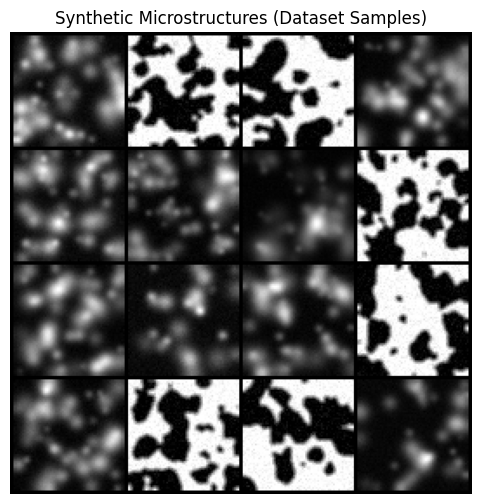

In [2]:
# 1) Generate a synthetic dataset (offline)
data_path = Path("data/notebook_demo.npz")
data_path, meta_path = build_and_save_dataset(
    out_path=data_path,
    num_samples=128,
    image_size=64,
    kind="mixed",
    seed=123,
)
images, labels, metadata = load_saved_dataset(data_path)
print("dataset:", images.shape, images.dtype, "labels:", labels.shape, labels.dtype)
print("metadata label counts:", metadata.get("label_counts", {}))

fig, ax = plt.subplots(figsize=(6, 6))
grid = make_grid(torch.from_numpy(images[:16]).unsqueeze(1), nrow=4, normalize=False)
ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0, vmax=1)
ax.set_title("Synthetic Microstructures (Dataset Samples)")
ax.axis("off")
plt.show()

In [10]:
# 2) Train VAE in fast mode
subprocess.run([
    sys.executable, "-m", "microgen.train_vae",
    "--fast", "--epochs", "15", "--num-samples", "384", "--batch-size", "64",
    "--seed", "123",
], check=True)


CompletedProcess(args=['c:\\MaterialsInformatics\\worked_examples\\codex_generative_materials\\.venv\\Scripts\\python.exe', '-m', 'microgen.train_vae', '--fast', '--epochs', '15', '--num-samples', '384', '--batch-size', '64', '--seed', '123'], returncode=0)

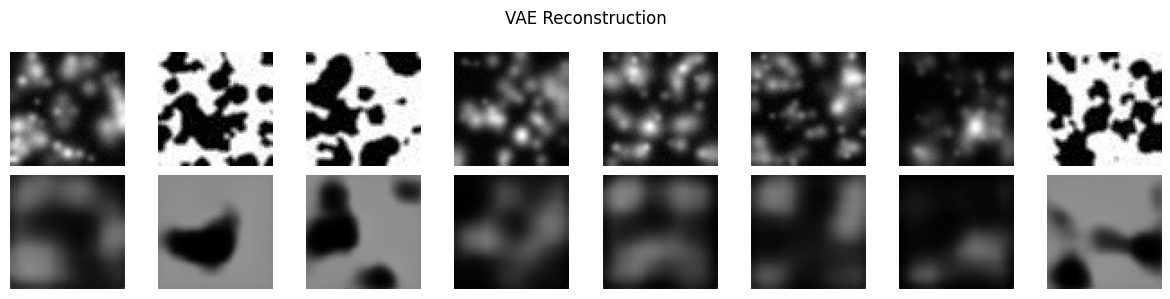

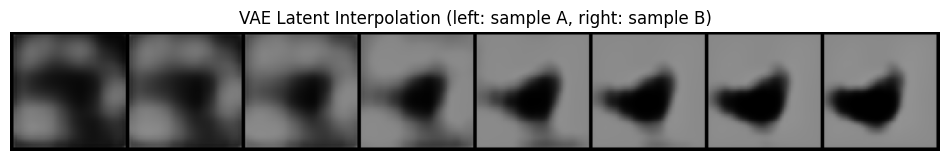

In [11]:
import microgen.models.vae as vae_mod
importlib.reload(vae_mod)
ConvVAE = vae_mod.ConvVAE

# VAE reconstruction + latent interpolation
ckpt_vae = torch.load("checkpoints/vae.pt", map_location=device)
vae = ConvVAE(latent_dim=ckpt_vae["config"]["latent_dim"]).to(device)
vae.load_state_dict(ckpt_vae["model_state"])
vae.eval()

x = torch.from_numpy(images[:8]).float().unsqueeze(1).to(device)
with torch.no_grad():
    mu, _ = vae.encode(x)
    recon = vae.decode(mu)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(x[i, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(recon[i, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Recon")
plt.suptitle("VAE Reconstruction")
plt.tight_layout()
plt.show()

xa = torch.from_numpy(images[0]).float().unsqueeze(0).unsqueeze(0).to(device)
xb = torch.from_numpy(images[1]).float().unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad():
    mu_a, _ = vae.encode(xa)
    mu_b, _ = vae.encode(xb)
    alphas = torch.linspace(0.0, 1.0, steps=8, device=device).unsqueeze(1)
    z_interp = (1 - alphas) * mu_a + alphas * mu_b
    x_interp = vae.decode(z_interp).cpu()

fig, ax = plt.subplots(figsize=(12, 2))
grid = make_grid(x_interp, nrow=8, normalize=False)
ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0, vmax=1)
ax.set_title("VAE Latent Interpolation (left: sample A, right: sample B)")
ax.axis("off")
plt.show()


In [6]:
# 3) Train GAN in fast mode
subprocess.run([
    sys.executable, "-m", "microgen.train_gan",
    "--fast", "--epochs", "16", "--num-samples", "384", "--batch-size", "64",
    "--d-steps", "2", "--instance-noise-std", "0.02",
    "--seed", "123",
], check=True)


CompletedProcess(args=['c:\\MaterialsInformatics\\worked_examples\\codex_generative_materials\\.venv\\Scripts\\python.exe', '-m', 'microgen.train_gan', '--fast', '--epochs', '16', '--num-samples', '384', '--batch-size', '64', '--d-steps', '2', '--instance-noise-std', '0.02', '--seed', '123'], returncode=0)

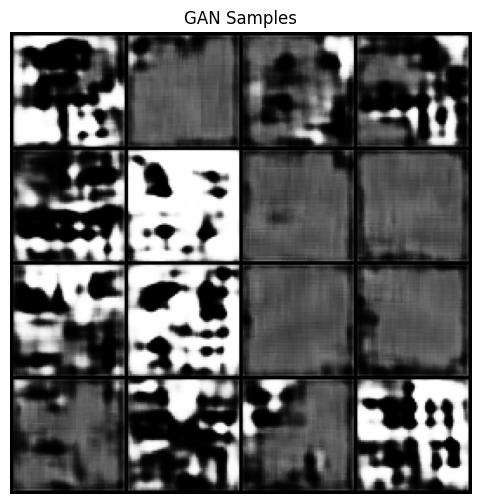

In [7]:
import microgen.models.gan as gan_mod
importlib.reload(gan_mod)
DCGenerator = gan_mod.DCGenerator

# GAN sampling
ckpt_gan = torch.load("checkpoints/gan.pt", map_location=device)
latent_dim = ckpt_gan["config"]["latent_dim"]
gen = DCGenerator(latent_dim=latent_dim).to(device)
gen.load_state_dict(ckpt_gan["generator_state"])
gen.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    samples = gen(z).cpu()

fig, ax = plt.subplots(figsize=(6, 6))
grid = make_grid(samples, nrow=4, normalize=True, value_range=(-1, 1))
ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
ax.set_title("GAN Samples")
ax.axis("off")
plt.show()

In [8]:
# 4) Train DDPM in fast mode
subprocess.run([
    sys.executable, "-m", "microgen.train_ddpm",
    "--fast", "--epochs", "8", "--num-samples", "384", "--batch-size", "64",
    "--timesteps", "100", "--seed", "123",
], check=True)


CompletedProcess(args=['c:\\MaterialsInformatics\\worked_examples\\codex_generative_materials\\.venv\\Scripts\\python.exe', '-m', 'microgen.train_ddpm', '--fast', '--epochs', '8', '--num-samples', '384', '--batch-size', '64', '--timesteps', '100', '--seed', '123'], returncode=0)

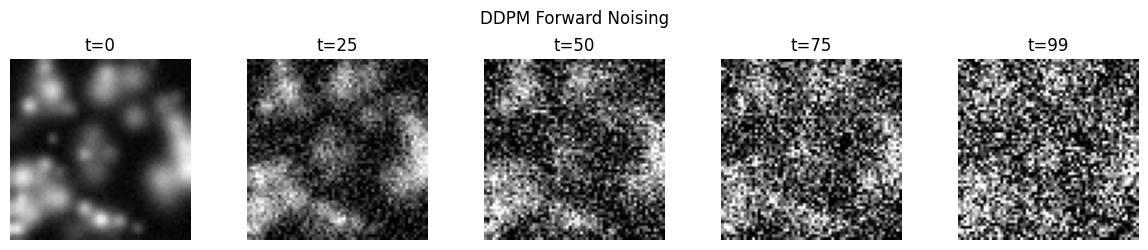

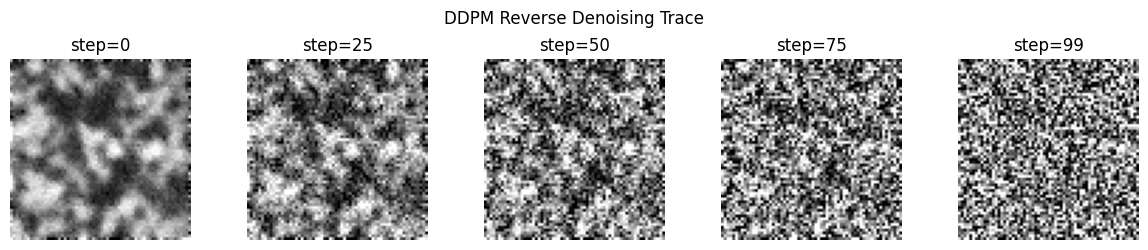

In [9]:
import microgen.models.ddpm as ddpm_mod
importlib.reload(ddpm_mod)
DiffusionSchedule = ddpm_mod.DiffusionSchedule
TinyUNet = ddpm_mod.TinyUNet

# DDPM denoising visualization
ckpt_ddpm = torch.load("checkpoints/ddpm.pt", map_location=device)
timesteps = ckpt_ddpm["config"]["timesteps"]
ddpm = TinyUNet(base_channels=32).to(device)
ddpm.load_state_dict(ckpt_ddpm["model_state"])
ddpm.eval()
schedule = DiffusionSchedule(timesteps=timesteps).to(device)

# Forward noising of one real sample
x0 = torch.from_numpy(images[0:1]).float().unsqueeze(1).to(device)
x0 = x0 * 2.0 - 1.0
forward_steps = [0, timesteps // 4, timesteps // 2, (3 * timesteps) // 4, timesteps - 1]
forward_imgs = []
for s in forward_steps:
    t = torch.tensor([s], device=device, dtype=torch.long)
    noise = torch.randn_like(x0)
    alpha_bar = schedule.alpha_bars[t].view(1, 1, 1, 1)
    xt = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * noise
    forward_imgs.append(xt.detach().cpu())

fig, axes = plt.subplots(1, len(forward_imgs), figsize=(12, 2.5))
for i, img in enumerate(forward_imgs):
    axes[i].imshow(((img[0, 0] + 1) / 2).clamp(0, 1), cmap="gray")
    axes[i].set_title(f"t={forward_steps[i]}")
    axes[i].axis("off")
plt.suptitle("DDPM Forward Noising")
plt.tight_layout()
plt.show()

# Reverse denoising trace from pure noise
trace_steps = sorted({0, timesteps // 4, timesteps // 2, (3 * timesteps) // 4, timesteps - 1})
trace_set = set(trace_steps)
x = torch.randn(1, 1, 64, 64, device=device)
captured = {}
with torch.no_grad():
    for step in range(timesteps - 1, -1, -1):
        t = torch.full((1,), step, device=device, dtype=torch.long)
        pred_noise = ddpm(x, t)
        alpha_t = schedule.alphas[t].view(1, 1, 1, 1)
        alpha_bar_t = schedule.alpha_bars[t].view(1, 1, 1, 1)
        beta_t = schedule.betas[t].view(1, 1, 1, 1)
        mean = (x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * pred_noise) / torch.sqrt(alpha_t)
        if step > 0:
            x = mean + torch.sqrt(beta_t) * torch.randn_like(x)
        else:
            x = mean
        if step in trace_set:
            captured[step] = x.detach().cpu()

fig, axes = plt.subplots(1, len(trace_steps), figsize=(12, 2.5))
for i, s in enumerate(trace_steps):
    img = ((captured[s][0, 0] + 1) / 2).clamp(0, 1)
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"step={s}")
    axes[i].axis("off")
plt.suptitle("DDPM Reverse Denoising Trace")
plt.tight_layout()
plt.show()